#### EDA - Análise Exploratória de Dados (EDA) 

1. Setup e carga do arquivo

In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utils.data_prep import create_label

# Estilo de visualização padrão
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Carrega o dataset bruto (.csv) contendo dados de telemetria dos dispositivos
df = pd.read_csv("../data/Moto_HW_DATA_hashed.csv")

# Seleciona apenas as colunas mais relevantes para o nosso problema
cols = [
    "full_cap_min", "btlow_total", "dchrg_diff", "total_chrg_cnt",
    "son_hrs", "msgs_tot", "wifi_hrs", "mobile_rx_MB"
]
df = df[cols]

2. Criação de rótulo de ineficiência

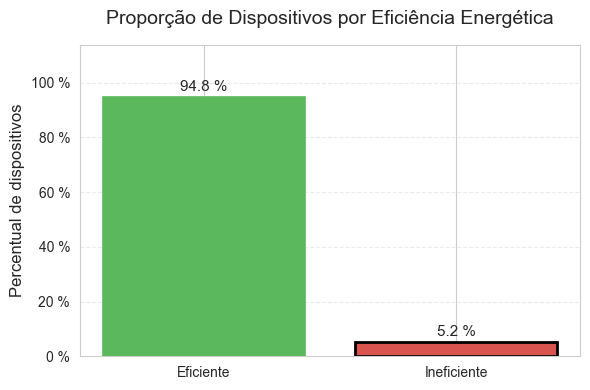

In [21]:


df = create_label(df)

# ── 4.  Checa proporção & plota ─────────────────────────────────
# 1) calcula o percentual de cada classe
counts = df["label_ineficiente"].value_counts().sort_index()
percentages = counts / counts.sum() * 100
# renomeia para algo mais legível
labels = ["Eficiente", "Ineficiente"]

# 2) cria o bar plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, percentages, edgecolor="black", linewidth=1.2)

# 3) anota cada barra com o seu percentual
for bar, pct in zip(bars, percentages):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 1, f"{pct:.1f} %", ha="center", va="bottom", fontsize=11)

# 4) destaca visualmente a barra de "Ineficiente"
bars[1].set_color("#d9534f")       # vermelho suave
bars[0].set_color("#5cb85c")       # verde suave
bars[1].set_edgecolor("black")
bars[1].set_linewidth(2)

# 5) refinamentos finais
ax.set_ylim(0, percentages.max() * 1.2)
ax.set_ylabel("Percentual de dispositivos", fontsize=12)
ax.set_title("Proporção de Dispositivos por Eficiência Energética", fontsize=14, pad=15)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x)} %")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

3. Visão geral

In [4]:
# Informações gerais do DataFrame (tipos, nulls, memória)
df.info()

# Estatísticas descritivas básicas para cada coluna
df.describe().T   


# Conta valores ausentes por coluna (se houver)
na = df.isna().sum().sort_values(ascending=False)
display(na[na > 0])   # Exibe apenas colunas com NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21063 entries, 0 to 21062
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_cap_min       21063 non-null  float64
 1   btlow_total        21063 non-null  float64
 2   dchrg_diff         21063 non-null  float64
 3   total_chrg_cnt     21063 non-null  float64
 4   son_hrs            21063 non-null  float64
 5   msgs_tot           11386 non-null  float64
 6   wifi_hrs           21063 non-null  float64
 7   mobile_rx_MB       21063 non-null  float64
 8   label_ineficiente  21063 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.4 MB


msgs_tot    9677
dtype: int64

,mean,std,skew,kurtosis
feature,,,,
btlow_total,23.399789,7.808618e+02,123.903613,16773.506771
wifi_hrs,12.355275,1.837340e+01,13.936419,377.447396
msgs_tot,96.929668,1.249211e+02,10.452005,272.042781
total_chrg_cnt,7.128694,1.301778e+01,8.074835,109.228733
mobile_rx_MB,108.330611,2.660867e+02,6.166605,70.123534
full_cap_min,333131.836940,1.105046e+06,3.200614,8.794286
dchrg_diff,71.769253,3.799376e+01,1.383958,7.623548
son_hrs,5.205605,2.769159e+00,0.510442,0.450503


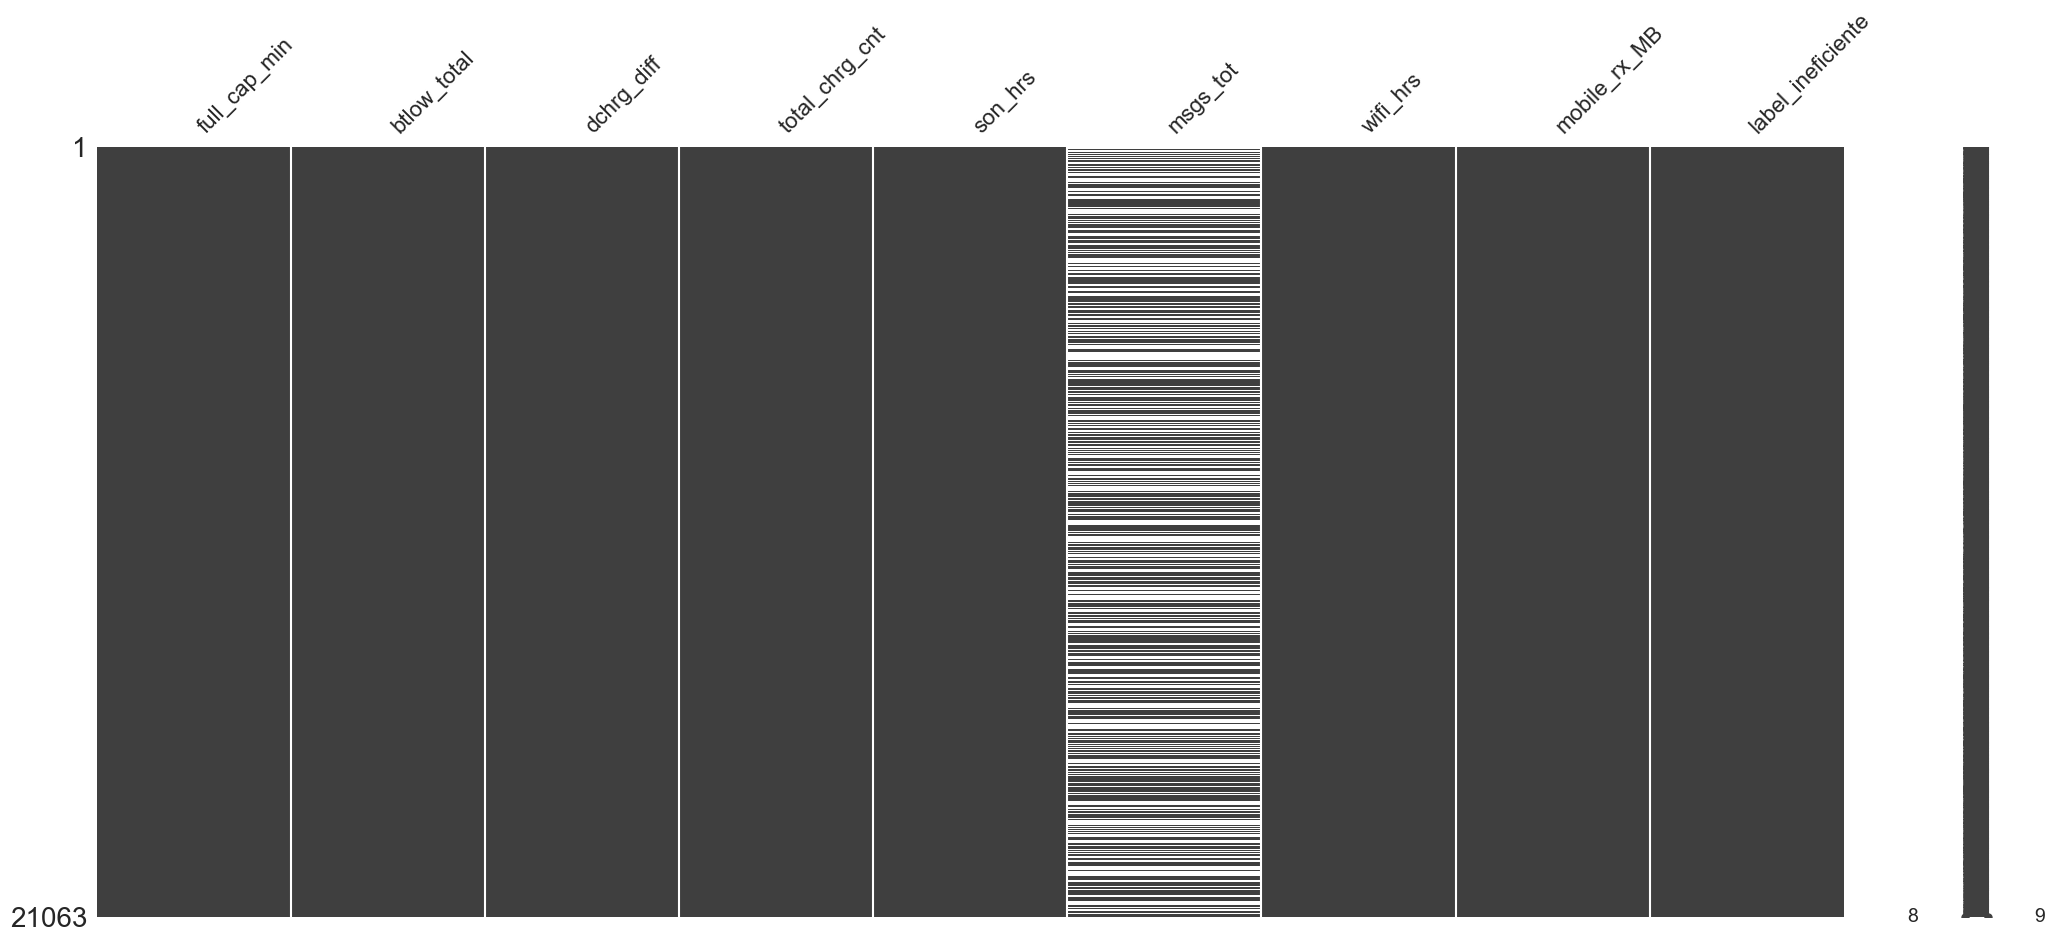

<Figure size 600x500 with 0 Axes>

In [5]:
# Importa bibliotecas para visualização de missing values e análise de forma da distribuição
import missingno as msno
from scipy.stats import skew, kurtosis

# --- Visualização gráfica de valores ausentes (linhas brancas = valores faltantes)
# Apenas a coluna msgs_tot mostra ausências, o que é excelente.
msno.matrix(df)
plt.savefig("../outputs/figures/eda_missing_matrix.png")

# --- Tabela de medidas estatísticas adicionais: skew (assimetria) e kurtosis (cauda)

# Para cada coluna, calcula estatísticas que ajudam a decidir se devemos aplicar transformação logarítmica
stats = []
stats = []

for col in cols:
    stats.append({
        "feature": col,
        "mean": df[col].mean(),
        "std": df[col].std(),
        "skew": skew(df[col].dropna()),
        "kurtosis": kurtosis(df[col].dropna())
    })

sk_table = pd.DataFrame(stats).set_index("feature").sort_values("skew", ascending=False)

display(sk_table)

# --- Mapa de calor de correlação entre variáveis numéricas
plt.figure(figsize=(6,5))
sns.heatmap(df[cols].corr(method="spearman"), cmap="vlag", center=0, annot=False)
plt.title("Correlação Spearman")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_corr.png")

# Comentário analítico:
# - Correlações baixas entre variáveis principais → bom sinal, pois evita multicolinearidade excessiva

# --- Distribuições de cada variável separadas por rótulo (ineficiente ou não)

for c in cols:
    sns.kdeplot(data=df, x=c, hue="label_ineficiente", common_norm=False)
    plt.title(f"{c} vs label")
    plt.savefig(f"../outputs/figures/eda_{c}_kde.png")
    plt.clf()
    
# Comentário analítico:
# - Permite observar se alguma variável "separa" bem os rótulos
# - Exemplo: full_cap_min tende a ser menor para aparelhos ineficientes

### 📌 Insights Extraídos
- Apenas `msgs_tot` possui valores ausentes (recomendado fillna).
- 6 variáveis apresentam alta assimetria (skew > 3) e devem ser transformadas com log1p.
- As variáveis `full_cap_min`, `btlow_total` e `wifi_hrs` mostram bom poder discriminativo para o rótulo.
- Correlações baixas entre variáveis: bom sinal para modelagem.